# Spatial Probability of Aftershocks Given an Identified Mainshock — Southeast Asia

**Data cleaning + 7 source-zone classification + EDA**

This notebook reproduces `scripts/01_clean_data.py`, `scripts/02_source_zones.py`,
and `scripts/03_eda.py` as one interactive workflow. Run cells top to bottom.

**Requirements:** run this notebook from the **repository root** (so the relative
paths `data/raw/...`, `data/processed/...`, `figures/...`, `reports/...` resolve
correctly), with `pandas`, `numpy`, `matplotlib`, `scipy` installed:

```bash
pip install pandas numpy matplotlib scipy
```

See `reports/02_eda_report.md` for the full written chapter (methodology,
findings, data-quality caveats, and next steps for the modeling stage).


In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure we're at the repo root (folder containing data/, scripts/, reports/)
assert os.path.isdir("data/raw"), (
    "Run this notebook from the repository root - 'data/raw' not found in "
    f"the current working directory ({os.getcwd()})."
)

os.makedirs("data/processed", exist_ok=True)
os.makedirs("reports", exist_ok=True)
os.makedirs("figures", exist_ok=True)


## Step 1 — Data cleaning and standardization

Combines two raw earthquake catalogs into a single, standardized catalog:
- **TMD** local earthquake catalog (Thai Meteorological Department), 2007-2026
  — note: the source file is **Windows-874 / TIS-620** encoded, not UTF-8.
- **USGS** regional catalog for Southeast Asia, 2012-2026.

Both are mapped to a common schema (`event_id, time_utc, lat, lon, depth_km,
mag, mag_type, network, place`), then deduplicated: larger regional events are
often reported by both networks, so any TMD event within 60s / 50km of a USGS
event is treated as the same earthquake and dropped in favor of the USGS
record (kept as network-of-record for shared events).


In [2]:
RAW_TMD = "data/raw/tmd_local_earthquake.csv"
RAW_USGS = "data/raw/usgs_combined_2012_2026.csv"


def load_tmd():
    df = pd.read_csv(RAW_TMD, encoding="cp874")
    df.columns = [c.strip() for c in df.columns]

    out = pd.DataFrame()
    out["event_id"] = "TMD_" + df["REF. ID"].astype(str).str.strip()
    out["time_utc"] = pd.to_datetime(df["DATE-TIME UTC"], errors="coerce")
    out["lat"] = pd.to_numeric(df["LAT."], errors="coerce")
    out["lon"] = pd.to_numeric(df["LONG."], errors="coerce")
    out["depth_km"] = pd.to_numeric(df["DEPTH."], errors="coerce")
    out["mag"] = pd.to_numeric(df["MAG."], errors="coerce")
    out["mag_type"] = "ML(TMD)"
    out["network"] = "TMD"
    # Source has two REGION columns (Thai description, sometimes English);
    # pandas renames the second to "REGION..1". Prefer Thai text, fall back to English.
    region_th = df["REGION."].astype(str).str.strip()
    region_en = df["REGION..1"].astype(str).str.strip() if "REGION..1" in df.columns else ""
    out["place"] = region_th.where(region_th.ne("") & region_th.ne("nan"), region_en)

    out = out.dropna(subset=["time_utc", "lat", "lon", "mag"])
    out = out[(out["lat"].between(-90, 90)) & (out["lon"].between(-180, 180))]
    out = out[out["mag"] > 0]
    return out


def load_usgs():
    df = pd.read_csv(RAW_USGS)
    df = df[df["type"] == "earthquake"]

    out = pd.DataFrame()
    out["event_id"] = "USGS_" + df["id"].astype(str)
    out["time_utc"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_localize(None)
    out["lat"] = pd.to_numeric(df["latitude"], errors="coerce")
    out["lon"] = pd.to_numeric(df["longitude"], errors="coerce")
    out["depth_km"] = pd.to_numeric(df["depth"], errors="coerce")
    out["mag"] = pd.to_numeric(df["mag"], errors="coerce")
    out["mag_type"] = df["magType"].astype(str)
    out["network"] = "USGS/" + df["net"].astype(str).str.upper()
    out["place"] = df["place"].astype(str)

    out = out.dropna(subset=["time_utc", "lat", "lon", "mag"])
    out = out[(out["lat"].between(-90, 90)) & (out["lon"].between(-180, 180))]
    out = out[out["mag"] > 0]
    return out


tmd = load_tmd()
usgs = load_usgs()
print(f"TMD:  {len(tmd)} events kept")
print(f"USGS: {len(usgs)} events kept")


TMD:  16656 events kept
USGS: 47151 events kept


In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


def dedupe(tmd, usgs):
    """Flag TMD events within 60s / 50km of a USGS event as duplicates and drop them."""
    tmd = tmd.sort_values("time_utc").reset_index(drop=True)
    usgs_sorted = usgs.sort_values("time_utc").reset_index(drop=True)
    u_times = usgs_sorted["time_utc"].values
    u_lat = usgs_sorted["lat"].values
    u_lon = usgs_sorted["lon"].values

    window = np.timedelta64(60, "s")
    is_dup = np.zeros(len(tmd), dtype=bool)
    lo = 0
    for i, t in enumerate(tmd["time_utc"].values):
        while lo < len(u_times) and u_times[lo] < t - window:
            lo += 1
        j = lo
        while j < len(u_times) and u_times[j] <= t + window:
            d = haversine_km(tmd["lat"].iloc[i], tmd["lon"].iloc[i], u_lat[j], u_lon[j])
            if d <= 50:
                is_dup[i] = True
                break
            j += 1
    return tmd.loc[~is_dup].reset_index(drop=True), int(is_dup.sum())


tmd_unique, n_dup = dedupe(tmd, usgs)
print(f"Dropped {n_dup} TMD events as duplicates of a USGS event.")

catalog = pd.concat([tmd_unique, usgs], ignore_index=True).sort_values("time_utc").reset_index(drop=True)
n_before = len(catalog)
catalog = catalog.drop_duplicates(subset=["network", "time_utc", "lat", "lon", "mag"])
print(f"Removed {n_before - len(catalog)} exact duplicate rows within the same network.")

catalog.to_csv("data/processed/catalog_clean.csv", index=False)
print(f"\nFinal combined catalog: {len(catalog)} events -> data/processed/catalog_clean.csv")
print(f"Time range: {catalog['time_utc'].min()} to {catalog['time_utc'].max()}")
print(f"Magnitude range: {catalog['mag'].min():.1f} to {catalog['mag'].max():.1f}")
print(f"\nEvents by network:\n{catalog['network'].value_counts().to_string()}")
catalog.head()


Dropped 1270 TMD events as duplicates of a USGS event.
Removed 31 exact duplicate rows within the same network.



Final combined catalog: 62506 events -> data/processed/catalog_clean.csv
Time range: 2007-01-04 08:38:00 to 2026-09-11 00:53:48.954000
Magnitude range: 0.6 to 8.6

Events by network:
network
USGS/US          47131
TMD              15374
USGS/OFFICIAL        1


,event_id,time_utc,lat,lon,depth_km,mag,mag_type,network,place
0,TMD_TM0001,2007-01-04 08:38:00,18.9,99.00,0.0,2.4,ML(TMD),TMD,อ.แม่ริม จ.เชียงใหม่
1,TMD_TM0002,2007-01-06 02:23:00,18.9,99.00,0.0,3.1,ML(TMD),TMD,อ.แม่ริม จ.เชียงใหม่
2,TMD_TM0003,2007-04-22 06:18:00,19.4,99.36,0.0,4.5,ML(TMD),TMD,อ.เวียงป่าเป้า จ.เชียงราย
3,TMD_TM0004,2007-04-23 14:18:00,19.6,99.20,0.0,4.0,ML(TMD),TMD,อ.พร้าว จ.เชียงใหม่
4,TMD_TM0005,2007-05-16 10:04:00,21.0,100.50,0.0,4.7,ML(TMD),TMD,พรมแดนลาว-พม่า


## Step 2 — Define 7 tectonic source zones and classify events

7 literature-informed, first-order approximation source zones for Southeast
Asia (coarse linear boundaries / bounding boxes — good enough for EDA, but
should be refined against an authoritative fault database, e.g. the GEM
Global Active Faults Database, before spatial-probability modeling):

| Code | Zone |
|---|---|
| Z1 | Sunda Megathrust – Sumatra Segment |
| Z2 | Great Sumatran Fault Zone |
| Z3 | Sunda Megathrust – Java to Nusa Tenggara |
| Z4 | Andaman-Nicobar-Myanmar Arc & Sagaing Fault System |
| Z5 | Shan-Thai / Indochina Intraplate Zone |
| Z6 | Philippine Mobile Belt |
| Z7 | Sulawesi - Molucca Sea - Banda Arc |


In [4]:
ZONES = [
    {"id": 1, "code": "Z1", "name": "Sunda Megathrust - Sumatra Segment"},
    {"id": 2, "code": "Z2", "name": "Great Sumatran Fault Zone"},
    {"id": 3, "code": "Z3", "name": "Sunda Megathrust - Java to Nusa Tenggara"},
    {"id": 4, "code": "Z4", "name": "Andaman-Nicobar-Myanmar Arc & Sagaing Fault System"},
    {"id": 5, "code": "Z5", "name": "Shan-Thai / Indochina Intraplate Zone"},
    {"id": 6, "code": "Z6", "name": "Philippine Mobile Belt"},
    {"id": 7, "code": "Z7", "name": "Sulawesi - Molucca Sea - Banda Arc"},
]
ZONE_NAME = {z["code"]: z["name"] for z in ZONES}


def sumatra_coast_lon(lat):
    """Approx. west-coast-of-Sumatra longitude vs. latitude, anchored on
    Banda Aceh (95.3, 5.5) and Bengkulu (102.3, -3.8)."""
    return 99.44 - 0.7527 * lat


def classify(lat, lon):
    if 92.0 <= lon <= 98.5 and 6.5 <= lat <= 28.5:
        return "Z4"
    if -7.0 <= lat <= 6.5 and lon <= 105.5:
        coast = sumatra_coast_lon(lat)
        if coast - 10.0 <= lon < coast - 0.3:
            return "Z1"
        if coast - 0.3 <= lon <= coast + 3.0:
            return "Z2"
    if 97.0 <= lon <= 110.0 and 5.0 <= lat <= 23.5:
        return "Z5"
    if 105.0 <= lon <= 126.0 and -11.5 <= lat <= -6.0:
        return "Z3"
    if 118.0 <= lon <= 127.5 and 4.0 <= lat <= 25.5:
        return "Z6"
    if 113.0 <= lon <= 135.0 and -11.0 <= lat <= 6.5:
        return "Z7"
    return "Unclassified"


# Sanity check against well-known landmark coordinates
checks = [
    ("Bangkok, Thailand", 13.75, 100.50, "Z5"),
    ("Chiang Mai, Thailand", 18.79, 98.98, "Z5"),
    ("Yangon, Myanmar", 16.80, 96.15, "Z4"),
    ("Banda Aceh, Indonesia (N. Sumatra)", 5.55, 95.32, "Z2"),
    ("Offshore W. Sumatra (2004 rupture area)", 3.30, 95.85, "Z1"),
    ("Jakarta, Indonesia (Java)", -6.21, 106.85, "Z3"),
    ("Manila, Philippines", 14.60, 120.98, "Z6"),
    ("Manado, Indonesia (N. Sulawesi)", 1.49, 124.85, "Z7"),
]
for name, lat, lon, expected in checks:
    got = classify(lat, lon)
    print(f"{'OK' if got == expected else 'MISMATCH':8s} {name:45s} -> {got} (expected {expected})")


OK       Bangkok, Thailand                             -> Z5 (expected Z5)
OK       Chiang Mai, Thailand                          -> Z5 (expected Z5)
OK       Yangon, Myanmar                               -> Z4 (expected Z4)
OK       Banda Aceh, Indonesia (N. Sumatra)            -> Z2 (expected Z2)
OK       Offshore W. Sumatra (2004 rupture area)       -> Z1 (expected Z1)
OK       Jakarta, Indonesia (Java)                     -> Z3 (expected Z3)
OK       Manila, Philippines                           -> Z6 (expected Z6)
OK       Manado, Indonesia (N. Sulawesi)               -> Z7 (expected Z7)


In [5]:
df = pd.read_csv("data/processed/catalog_clean.csv", parse_dates=["time_utc"])
df["zone_code"] = [classify(la, lo) for la, lo in zip(df["lat"], df["lon"])]
df["zone_name"] = df["zone_code"].map(ZONE_NAME).fillna("Outside defined source zones")

print("Event counts by zone:")
print(df["zone_code"].value_counts().to_string())

df.to_csv("data/processed/catalog_with_zones.csv", index=False)
pd.DataFrame(ZONES).to_csv("data/processed/source_zone_definitions.csv", index=False)
df.head()


Event counts by zone:
zone_code
Z7              16460
Z6              13435
Z4               9156
Z5               8656
Z3               5277
Unclassified     4810
Z1               3123
Z2               1589


,event_id,time_utc,lat,lon,depth_km,mag,mag_type,network,place,zone_code,zone_name
0,TMD_TM0001,2007-01-04 08:38:00,18.9,99.00,0.0,2.4,ML(TMD),TMD,อ.แม่ริม จ.เชียงใหม่,Z5,Shan-Thai / Indochina Intraplate Zone
1,TMD_TM0002,2007-01-06 02:23:00,18.9,99.00,0.0,3.1,ML(TMD),TMD,อ.แม่ริม จ.เชียงใหม่,Z5,Shan-Thai / Indochina Intraplate Zone
2,TMD_TM0003,2007-04-22 06:18:00,19.4,99.36,0.0,4.5,ML(TMD),TMD,อ.เวียงป่าเป้า จ.เชียงราย,Z5,Shan-Thai / Indochina Intraplate Zone
3,TMD_TM0004,2007-04-23 14:18:00,19.6,99.20,0.0,4.0,ML(TMD),TMD,อ.พร้าว จ.เชียงใหม่,Z5,Shan-Thai / Indochina Intraplate Zone
4,TMD_TM0005,2007-05-16 10:04:00,21.0,100.50,0.0,4.7,ML(TMD),TMD,พรมแดนลาว-พม่า,Z5,Shan-Thai / Indochina Intraplate Zone


## Step 3 — Exploratory data analysis

Spatial distribution, Gutenberg-Richter frequency-magnitude / b-values,
temporal completeness, and depth distribution, all broken down by source zone.


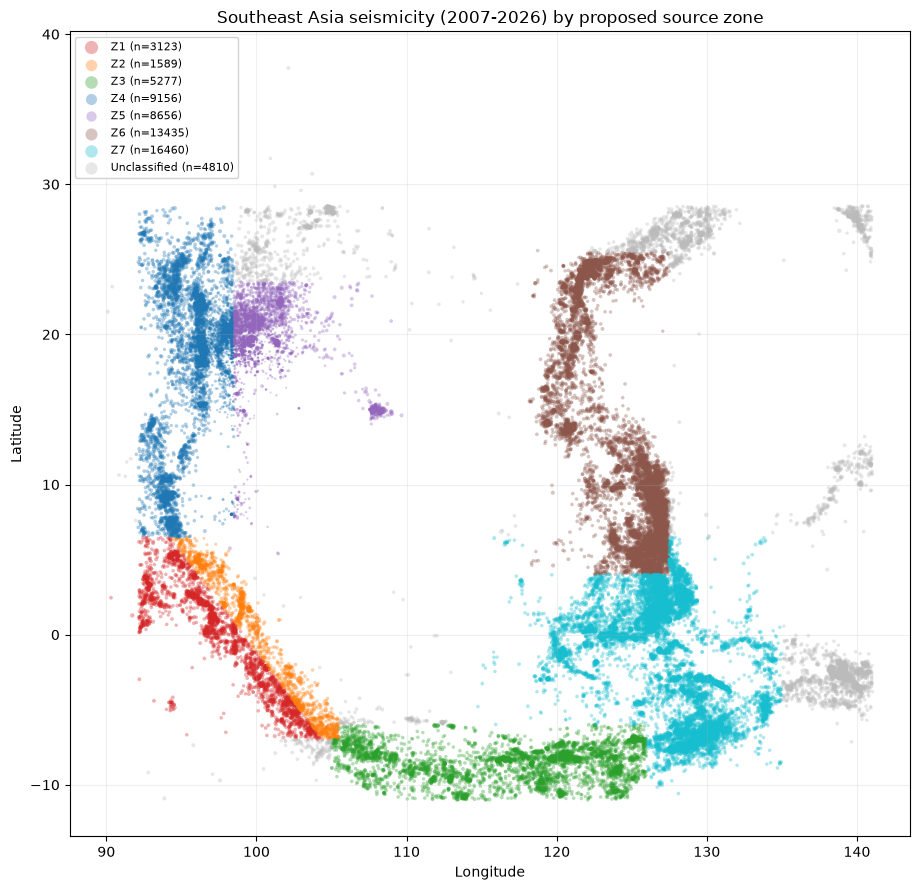

In [6]:
ZONE_ORDER = ["Z1", "Z2", "Z3", "Z4", "Z5", "Z6", "Z7", "Unclassified"]
ZONE_COLOR = {
    "Z1": "#d62728", "Z2": "#ff7f0e", "Z3": "#2ca02c", "Z4": "#1f77b4",
    "Z5": "#9467bd", "Z6": "#8c564b", "Z7": "#17becf", "Unclassified": "#bbbbbb",
}

fig, ax = plt.subplots(figsize=(11, 9))
for zone in ZONE_ORDER:
    sub = df[df["zone_code"] == zone]
    if len(sub) == 0:
        continue
    ax.scatter(sub["lon"], sub["lat"], s=np.clip((sub["mag"] - 1) * 2, 1, None),
               color=ZONE_COLOR[zone], alpha=0.35, linewidths=0, label=f"{zone} (n={len(sub)})")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Southeast Asia seismicity (2007-2026) by proposed source zone")
ax.set_aspect("equal")
ax.legend(markerscale=3, fontsize=8, loc="upper left", framealpha=0.9)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig("figures/01_event_map.png", dpi=150)
plt.show()


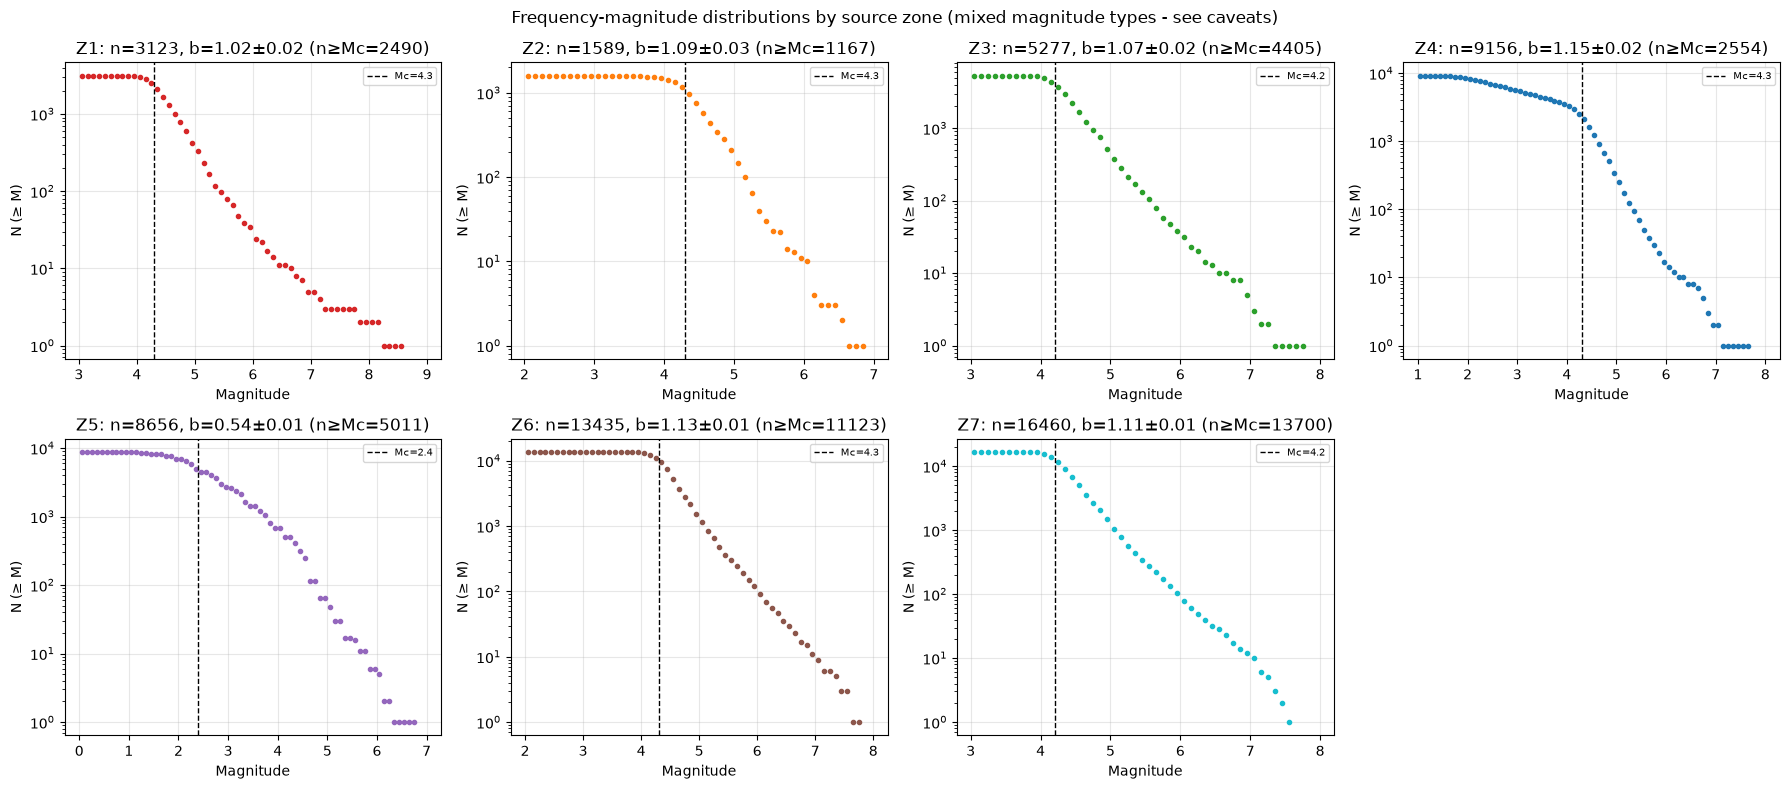

In [7]:
def max_curvature_mc(mags, dm=0.1):
    """Completeness magnitude via maximum curvature: the FMD's modal bin."""
    bins = np.arange(np.floor(mags.min() / dm) * dm, mags.max() + dm, dm)
    counts, edges = np.histogram(mags, bins=bins)
    if counts.sum() == 0:
        return np.nan
    return edges[np.argmax(counts)]


def aki_utsu_b_value(mags, mc, dm=0.1):
    """Maximum-likelihood b-value (Aki 1965 / Utsu 1965) for events >= mc."""
    m = mags[mags >= mc - dm / 2]
    n = len(m)
    if n < 30:
        return np.nan, np.nan, n
    mean_m = m.mean()
    b = np.log10(np.e) / (mean_m - (mc - dm / 2))
    return b, b / np.sqrt(n), n


zones = [z for z in ZONE_ORDER if z != "Unclassified"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
dm = 0.1
gr_rows = []
for i, zone in enumerate(zones):
    ax = axes[i]
    sub = df[df["zone_code"] == zone]
    mags = sub["mag"].dropna().values
    if len(mags) < 30:
        ax.set_title(f"{zone} (n={len(mags)}, too few events)")
        continue
    mc = max_curvature_mc(mags, dm)
    b, b_std, n_above = aki_utsu_b_value(mags, mc, dm)

    bins = np.arange(np.floor(mags.min()), np.ceil(mags.max()) + dm, dm)
    counts, edges = np.histogram(mags, bins=bins)
    centers = edges[:-1] + dm / 2
    cum = np.cumsum(counts[::-1])[::-1]

    ax.semilogy(centers, cum, "o", ms=3, color=ZONE_COLOR[zone])
    ax.axvline(mc, color="k", ls="--", lw=1, label=f"Mc={mc:.1f}")
    ax.set_title(f"{zone}: n={len(mags)}, b={b:.2f}\u00b1{b_std:.2f} (n\u2265Mc={n_above})")
    ax.set_xlabel("Magnitude"); ax.set_ylabel("N (\u2265 M)")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    gr_rows.append({"zone_code": zone, "mc": mc, "b_value": b, "b_value_std": b_std, "n_events_ge_mc": n_above})
for j in range(len(zones), len(axes)):
    axes[j].axis("off")
fig.suptitle("Frequency-magnitude distributions by source zone (mixed magnitude types - see caveats)")
fig.tight_layout()
fig.savefig("figures/02_magnitude_frequency.png", dpi=150)
plt.show()


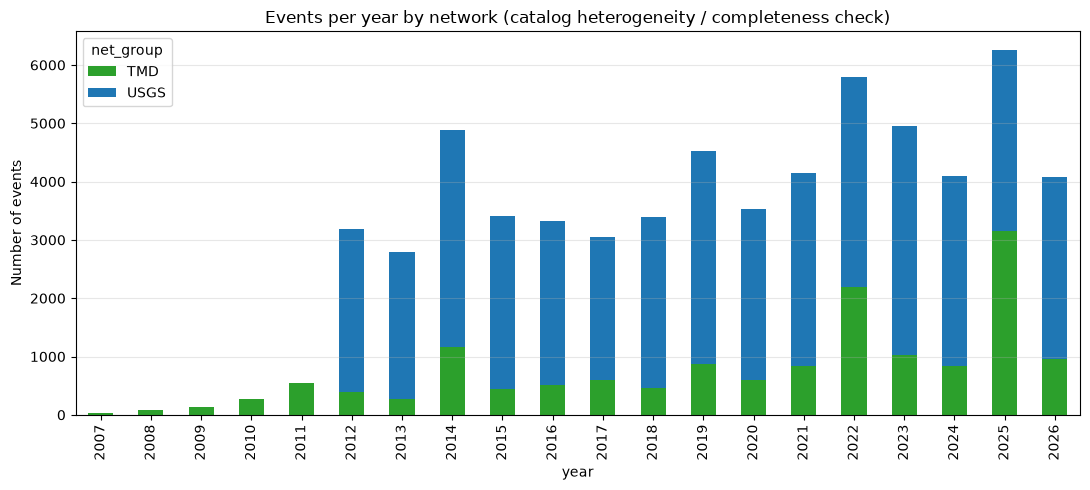

In [8]:
tmp = df.copy()
tmp["year"] = pd.to_datetime(tmp["time_utc"]).dt.year
tmp["net_group"] = tmp["network"].apply(lambda x: "TMD" if x == "TMD" else "USGS")
pivot = tmp.pivot_table(index="year", columns="net_group", values="event_id", aggfunc="count").fillna(0)

fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(kind="bar", stacked=True, ax=ax, color={"TMD": "#2ca02c", "USGS": "#1f77b4"})
ax.set_ylabel("Number of events")
ax.set_title("Events per year by network (catalog heterogeneity / completeness check)")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig("figures/03_temporal_distribution.png", dpi=150)
plt.show()


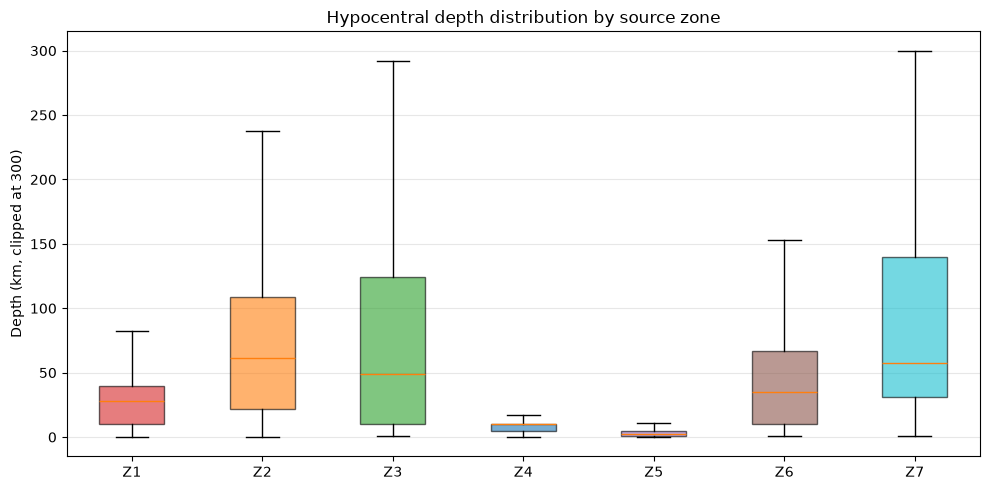

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
data = [df.loc[df["zone_code"] == z, "depth_km"].dropna().clip(upper=300) for z in zones]
bp = ax.boxplot(data, tick_labels=zones, showfliers=False, patch_artist=True)
for patch, zone in zip(bp["boxes"], zones):
    patch.set_facecolor(ZONE_COLOR[zone]); patch.set_alpha(0.6)
ax.set_ylabel("Depth (km, clipped at 300)")
ax.set_title("Hypocentral depth distribution by source zone")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig("figures/04_depth_histogram.png", dpi=150)
plt.show()


In [10]:
rows = []
for zone in ZONE_ORDER:
    sub = df[df["zone_code"] == zone]
    if len(sub) == 0:
        continue
    rows.append({
        "zone_code": zone, "n_events": len(sub), "mag_min": sub["mag"].min(),
        "mag_max": sub["mag"].max(), "depth_median_km": sub["depth_km"].median(),
        "time_min": sub["time_utc"].min(), "time_max": sub["time_utc"].max(),
    })
summary = pd.DataFrame(rows).merge(pd.DataFrame(gr_rows), on="zone_code", how="left")
summary.to_csv("reports/zone_summary.csv", index=False)
summary


,zone_code,n_events,mag_min,mag_max,depth_median_km,time_min,time_max,mc,b_value,b_value_std,n_events_ge_mc
0,Z1,3123,3.40,8.6,28.070,2007-11-10 23:20:00.000,2026-09-05 09:14:15.563,4.3,1.024920,0.020540,2490.0
1,Z2,1589,2.70,6.9,61.530,2007-10-01 14:03:00.000,2026-09-09 00:23:19.728,4.3,1.093065,0.031997,1167.0
2,Z3,5277,3.40,7.8,49.180,2012-01-01 08:59:52.110,2026-09-08 21:42:22.442,4.2,1.070697,0.016132,4405.0
3,Z4,9156,1.00,7.7,10.000,2007-10-09 02:35:00.000,2026-09-10 02:00:16.000,4.3,1.147539,0.022707,2554.0
4,Z5,8656,0.60,6.7,2.000,2007-01-04 08:38:00.000,2026-09-10 01:23:18.000,2.4,0.539874,0.007627,5011.0
5,Z6,13435,2.60,7.8,35.000,2012-01-04 06:59:56.950,2026-09-09 07:07:03.319,4.3,1.125857,0.010675,11123.0
6,Z7,16460,3.40,7.6,57.745,2012-01-01 01:22:07.660,2026-09-11 00:53:48.954,4.2,1.110230,0.009485,13700.0
7,Unclassified,4810,2.77,7.8,20.065,2008-03-02 18:26:00.000,2026-09-02 00:04:55.294,NaN,NaN,NaN,NaN


## Next steps (not yet implemented)

1. **Mainshock-aftershock declustering** (Gardner-Knopoff / Reasenberg / ETAS-based).
2. **Spatial probability model**: Omori-Utsu spatial decay kernel, full ETAS
   spatial kernel, or a gridded logistic/ML model using distance, azimuth
   relative to the zone trend, mainshock depth, and zone ID as features.
3. Train/validate per zone (event counts and b-values differ a lot across zones).
4. Refine the 7 zone boundaries with an authoritative fault database before
   computing mainshock-aftershock distances in the final model.

See `reports/02_eda_report.md` for the full discussion, including the
Z5 b-value anomaly and other data-quality caveats.
